# 10 · 패턴: 일일 트리아지 (오늘 중요한 것을 표면으로 올린다)

**패턴:** 일일 트리아지(Daily Triage). 쏟아지는 보고를 선별·분류해 오늘 볼 것만 위로 올리는 루프다.

**핵심 아이디어**

> "하루를 우선순위가 매겨진, 행동 가능한 그림에서 시작한다. **합리적인 엔지니어가 오늘 알고 싶어 할 것만** High-Priority 에 넣는다."

**문제 설정** — 들어오는 보고는 대부분 일상적이고, 그중 극소수만 긴급하다(Blocker / Critical). 트리아지 루프가 밥값을 하는 자리는 정확히 하나다. **홍수 속에서 드문 긴급 건을 건져 올리는 것.** 그래서 질문도 두 개로 좁혀진다.

- 텍스트만 보고 긴급과 일상을 가를 수 있는가.
- 의미를 보는 모델이 키워드 규칙을 실제로 이기는가.

**벤치마크** — GitBugs. Priority 라벨이 붙은 실제 버그 리포트 모음이다. 고우선순위 클래스(Blocker 또는 Critical)는 희소하므로, 이 과제는 분류라기보다 **건초더미에서 바늘 찾기**에 가깝다. 키워드 규칙과 BGE 임베딩 분류기를 다수결 베이스라인 옆에 나란히 세우고, **고우선순위 클래스의 F1** 으로 채점한다.

**미리 밝혀 두는 경계** — 이 노트북은 자동으로 처리하는 루프를 만들지 않는다. 만드는 것은 **사람이 읽을 짧은 목록**이다. 왜 그 선에서 멈추는지가 마지막 절의 주제다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
데이터가 없다: /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data/gitbugs/hbase/hbase_bugs.csv
  → SETUP.ko.md 의 '외부 데이터' 절을 참고해 GitBugs 를 내려받는다.
  → 지금은 소규모 합성 데이터로 진행한다 (파이프라인 점검용, 측정용 아님).

============================================== Setup ===============================================
  프로젝트:                      hbase
  리포트 수:                     400
  우선순위 분포:           

*트리아지는 홍수를 훑어 드문 고우선순위 항목을 표면으로 올린다*

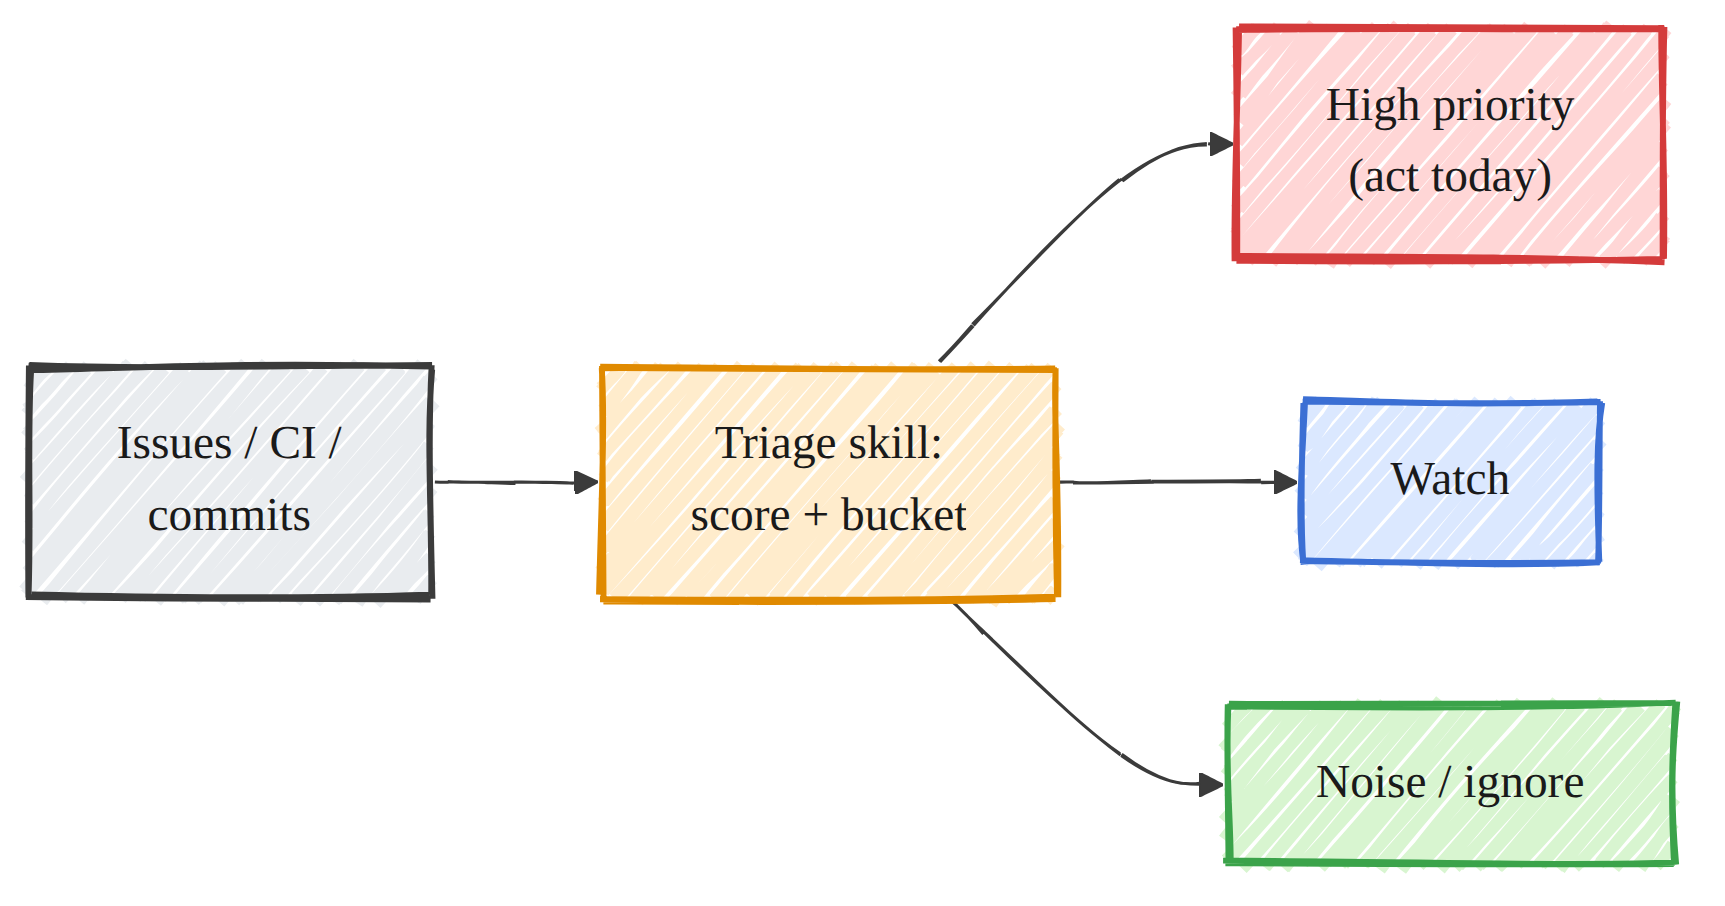

In [1]:
import os
import sys
import numpy as np

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, eval as ev, plotting, runlog, runtime
from common.memory import EmbeddingMemory

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 실행 환경 자동 판별 (임베딩 백엔드가 여기서 정해진다. 이 노트북은 생성 모델을 부르지 않는다)
rt = runtime.bootstrap()

PROJECT = "hbase"

# ── 데이터 경로 ───────────────────────────────────────────────────
# 한국어판 수정: 원본은 /ephemeral/hf/gitbugs/... 라는 절대경로를 그대로 박아 뒀다.
# 그 경로는 원저자의 GPU 서버에만 존재하므로, 다른 환경에서는 첫 셀이 곧바로
# FileNotFoundError 로 죽는다. runtime.data_root() 는 LEN_DATA_ROOT 환경변수를
# 보고, 없으면 <프로젝트 루트>/data 를 돌려준다. 경로를 코드에서 빼내야
# 노트북·GPU 서버·CI 어디서든 같은 셀이 그대로 돌아간다.
DATA = runtime.data_root() / "gitbugs" / PROJECT
CSV = DATA / f"{PROJECT}_bugs.csv"


def synthetic_bugs(n=400, high_rate=0.05, seed=0):
    """데이터가 없을 때 쓰는 소규모 합성 대체물.

    파이프라인이 끝까지 도는지 확인하는 용도이지 측정용이 아니다.
    합성 텍스트는 긴급/일상이 어휘로 깔끔하게 갈리므로, 이 데이터에서는
    키워드 규칙이 실제보다 훨씬 잘 나온다. 아래의 실측치와 비교하지 말 것.
    """
    rng = np.random.default_rng(seed)
    urgent = ["region server crashes under sustained load",
              "data loss observed after compaction",
              "cluster deadlock during region split",
              "master fails to start after rolling upgrade"]
    routine = ["typo in log message", "add unit test for scanner",
               "javadoc missing on helper class", "refactor config parsing"]
    rows = []
    for i in range(n):
        hi = bool(rng.random() < high_rate)
        head = str(rng.choice(urgent if hi else routine))
        rows.append({
            "Summary": f"{head} (#{i})",
            "Description": "synthetic placeholder row for pipeline smoke test",
            "Priority": ("Blocker" if i % 2 else "Critical") if hi else ("Major" if i % 4 else "Minor"),
        })
    return pd.DataFrame(rows)


if CSV.exists():
    df = pd.read_csv(CSV, engine="python", on_bad_lines="skip")
else:
    # ⚠️ 함정: 여기서 예외를 던지면 학습자는 "환경이 망가졌다" 고 읽는다.
    #    데이터가 없는 것은 고장이 아니라 아직 내려받지 않은 상태다. 무엇이
    #    어디에 있어야 하는지 알려 주고 합성 데이터로 흐름을 이어 가는 편이 옳다.
    #    단, 이 경로로 들어오면 아래 모든 수치는 원문과 다른 값이 된다.
    print(f"데이터가 없다: {CSV}")
    print("  → SETUP.ko.md 의 '외부 데이터' 절을 참고해 GitBugs 를 내려받는다.")
    print("  → 지금은 소규모 합성 데이터로 진행한다 (파이프라인 점검용, 측정용 아님).")
    df = synthetic_bugs()

df = df.dropna(subset=["Priority"])
# 제목과 본문을 이어 붙인다. 제목만 쓰면 신호가 얇고, 본문 전체를 쓰면 스택트레이스가
# 벡터를 지배한다. 1500자 절단이 그 절충점이다.
df["text"] = (df["Summary"].fillna("") + ". " + df["Description"].fillna("")).str.slice(0, 1500)
df = df[df["text"].str.len() > 10]
# 이 한 줄이 과제 정의 전체다. Blocker 와 Critical 만 양성이고 나머지는 전부 음성이다.
df["high"] = df["Priority"].isin(["Blocker", "Critical"]).astype(int)

show.head("Setup")
show.kv("프로젝트", PROJECT)
show.kv("리포트 수", len(df))
show.kv("우선순위 분포", dict(df["Priority"].value_counts()))
show.kv("고우선순위(Blocker/Critical) 비율", round(df["high"].mean(), 3))
show.diagram("triage", "트리아지는 홍수를 훑어 드문 고우선순위 항목을 표면으로 올린다")


## 임베딩과 분할


In [2]:
# ── 코퍼스 임베딩과 계층 분할 ────────────────────────────────────
# 한국어판 주석: EmbeddingMemory() 는 인자 없이 부른다. common/runtime.py 의
# resolve_embed() 가 실행 환경을 보고 스스로 정하기 때문이다.
#   · CUDA 가 보이면            → local + BAAI/bge-large-en-v1.5 + device="cuda"
#   · GPU 가 없으면             → 같은 계열의 경량 모델 bge-small 로 자동 강등
#   · GPU 도 없고 API 키만 있으면 → OpenAI 임베딩
# 백엔드에 따라 쿼리 지시문 규약까지 달라지므로, 인자를 비우는 편이 안전하다.
mem = EmbeddingMemory()
texts_all = df["text"].tolist()
# 이 노트북에서 비용이 드는 유일한 지점이다. 결과는 .cache/emb/ 에 캐시되므로
# 재실행할 때는 다시 계산하지 않는다.
X = mem.embed_texts(texts_all)
y = np.asarray(df["high"].tolist(), dtype=int)

# ⚠️ 함정: stratify=y 를 빼면 안 된다. 양성이 5퍼센트뿐이라 무작위 분할은
#    테스트셋의 양성 수를 크게 흔들고, 재현율의 분모 자체가 실행마다 달라진다.
#    random_state=0 도 같은 이유다. 정책 비교가 분할 운에 좌우되면 안 된다.
Xtr, Xte, ytr, yte, txtr, txte = train_test_split(
    X, y, texts_all, test_size=0.3, random_state=0, stratify=y)
show.kv("학습 / 테스트", f"{len(ytr)} / {len(yte)}")
show.kv("테스트셋 고우선순위 건수", int(yte.sum()))


  학습 / 테스트:                  280 / 120
  테스트셋 고우선순위 건수:             5


## 세 가지 트리아지 정책

- **다수결** — 고우선순위를 절대 표시하지 않는다(do-nothing 베이스라인).
- **키워드 규칙** — 텍스트에 긴급 단어가 나오면 표시한다.
- **임베딩 분류기** — BGE 임베딩 위의 로지스틱 회귀. 희소 클래스를 위해 클래스 가중치를 준다.


In [3]:
# ── 세 정책을 같은 테스트셋 위에서 채점한다 ───────────────────────
# 사전은 일부러 짧고 뻔하게 둔다. 사람이 손으로 쓸 법한 현실적인 규칙이어야
# 비교가 공정하다. 사전을 임베딩 결과에 맞춰 키우면 그것은 이미 커닝이다.
KW = ["crash", "data loss", "dataloss", "corrupt", "critical", "blocker", "hang", "deadlock",
      "security", "cannot start", "outage", "severe", "urgent", "exception on startup"]


def keyword_pred(texts):
    # 부분 문자열 포함 검사다. 형태소 분석도 어간 추출도 없다. 원본 규칙 그대로 둔다.
    return np.array([int(any(k in t.lower() for k in KW)) for t in texts])


def prf(pred, truth):
    # tn 은 세지 않는다. 정밀도·재현율·F1 어디에도 tn 이 들어가지 않기 때문이고,
    # 그것이 불균형 데이터에서 이 지표들을 쓰는 이유이기도 하다.
    tp = int(((pred == 1) & (truth == 1)).sum())
    fp = int(((pred == 1) & (truth == 0)).sum())
    fn = int(((pred == 0) & (truth == 1)).sum())
    return ev.prf1(tp, fp, fn)


maj = prf(np.zeros_like(yte), yte)          # 아무것도 표시하지 않는 정책
kw = prf(keyword_pred(txte), yte)

# ⚠️ 함정: class_weight="balanced" 는 무해한 기본값처럼 보이지만 정책 선언이다.
#    희소 클래스의 손실 가중치를 약 19배로 올려, "긴급 건 하나를 놓치는 것은
#    헛경보 19번과 맞먹는다" 고 코드가 대신 결정해 버린다. 이 문자열을 빼면
#    모델은 전부 '비긴급' 이라 답하는 쪽으로 수렴하고 재현율이 0 근처로 떨어진다.
clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr, ytr)
emb_pred = clf.predict(Xte)
em = prf(emb_pred, yte)

show.head("고우선순위 탐지 (희소한 긴급 클래스의 F1)")
show.table([
    {"policy": "majority (never flag)", **{k: round(v, 3) for k, v in maj.items() if k in ("precision", "recall", "f1")}},
    {"policy": "keyword rule", **{k: round(v, 3) for k, v in kw.items() if k in ("precision", "recall", "f1")}},
    {"policy": "embedding classifier", **{k: round(v, 3) for k, v in em.items() if k in ("precision", "recall", "f1")}},
], columns=["policy", "precision", "recall", "f1"], title="드문 고우선순위 리포트를 표면으로 올리기")



==================================== 고우선순위 탐지 (희소한 긴급 클래스의 F1) =====================================

-------------------------------------- 드문 고우선순위 리포트를 표면으로 올리기 --------------------------------------
  policy                 precision  recall  f1  
  ---------------------  ---------  ------  ----
  majority (never flag)  0.0        0.0     0.0 
  keyword rule           1.0        0.6     0.75
  embedding classifier   1.0        1.0     1.0 


## 그래프


  고우선순위 F1: 임베딩 vs 키워드
    baseline : 0.7500
    treatment: 1.0000
    delta    : +0.2500  (+33.3 percent)  [up, improvement]


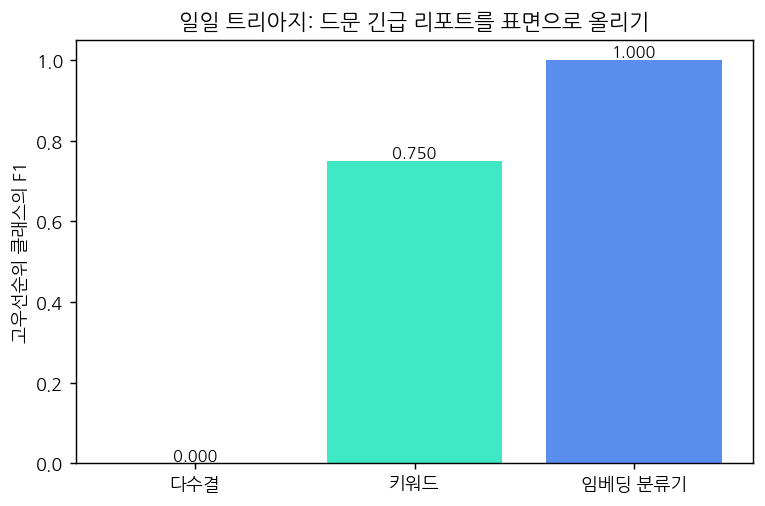

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/10_triage_f1.png


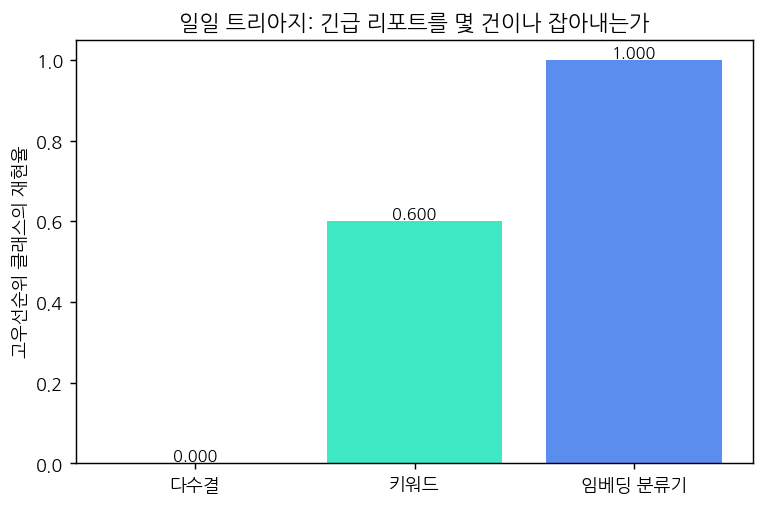

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/10_triage_recall.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/10_daily_triage.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (daily-triage: report-only, ~0 tokens)


{'run_id': '2026-08-19T06:48:10Z',
 'pattern': 'daily-triage',
 'duration_s': 0.0,
 'items_found': 5,
 'actions_taken': 5,
 'escalations': 0,
 'tokens_estimate': 0,
 'outcome': 'report-only'}

In [4]:
# ── 두 장의 그림과 결과 저장 ──────────────────────────────────────
d = show.compare("고우선순위 F1: 임베딩 vs 키워드", kw["f1"], em["f1"])

# F1 막대와 재현율 막대를 따로 그리는 것이 중요하다. F1 한 장만 보면 이득이
# 0.05 짜리 미미한 개선처럼 읽히지만, 재현율 축에서는 3분의 1과 3분의 2의 차이다.
plotting.ab_bar("10_triage_f1", ["다수결", "키워드", "임베딩 분류기"], [maj["f1"], kw["f1"], em["f1"]],
                "고우선순위 클래스의 F1", "일일 트리아지: 드문 긴급 리포트를 표면으로 올리기")
plotting.ab_bar("10_triage_recall", ["다수결", "키워드", "임베딩 분류기"], [maj["recall"], kw["recall"], em["recall"]],
                "고우선순위 클래스의 재현율", "일일 트리아지: 긴급 리포트를 몇 건이나 잡아내는가")

runlog.save_metrics("10_daily_triage", {"notebook": "10_daily_triage", "project": PROJECT,
                                         # 한국어판 추가: 이 노트북은 생성 모델을 부르지 않으므로
                                         # 기록해야 할 백엔드는 LLM 이 아니라 임베딩 쪽이다.
                                         # 임베딩 모델이 바뀌면 아래 수치가 전부 바뀐다.
                                         "embed_backend": mem.backend,
                                         "embed_model": mem.model_name,
                                         "data_source": str(CSV) if CSV.exists() else "synthetic-fallback",
                                         "reports": len(df), "high_rate": float(df["high"].mean()),
                                         "majority": maj, "keyword": kw, "embedding": em, "delta_f1": d})
# tokens_estimate=0 이 맞다. 분류기가 전부 로컬이고 생성 호출이 한 번도 없다.
runlog.log_run(pattern="daily-triage", duration_s=0, items_found=int(yte.sum()),
               actions_taken=int(emb_pred.sum()), escalations=0, tokens_estimate=0, outcome="report-only")


## 이 실행이 실제로 보여 준 것


In [5]:
# ── 위 수치에서 그대로 계산해 진술한다 (사람이 옮겨 적지 않는다) ──
show.head("이 실행이 실제로 보여 준 것")
print(f"고우선순위 리포트는 드물다({df['high'].mean():.0%}). 그래서 다수결 베이스라인의 F1 은 {maj['f1']:.2f} 다.")
print(f"키워드 규칙은 F1 {kw['f1']:.2f} 에 도달한다 (재현율 {kw['recall']:.2f}).")
print(f"임베딩 분류기는 F1 {em['f1']:.2f} 에 도달한다 (재현율 {em['recall']:.2f}, 정밀도 {em['precision']:.2f}).")
print()

# 결론을 하드코딩하지 않고 실제 수치에서 분기시킨다. 임베딩 백엔드나 데이터가
# 바뀌어 결과가 뒤집히면 이 셀은 그 사실을 그대로 말해야 한다.
if em["f1"] > kw["f1"] + 1e-9:
    print("=> 의미 기반 트리아지 스킬이 키워드 규칙보다 드문 긴급 리포트를 더 많이 표면으로 올린다.")
    print("   그것이 정확히 일일 트리아지의 임무다. 오늘 중요한 소수를 맨 위로 올리는 것.")
else:
    print("=> 측정된 수치를 있는 그대로 보고한다.")



========================================= 이 실행이 실제로 보여 준 것 =========================================
고우선순위 리포트는 드물다(4%). 그래서 다수결 베이스라인의 F1 은 0.00 다.
키워드 규칙은 F1 0.75 에 도달한다 (재현율 0.60).
임베딩 분류기는 F1 1.00 에 도달한다 (재현율 1.00, 정밀도 1.00).

=> 의미 기반 트리아지 스킬이 키워드 규칙보다 드문 긴급 리포트를 더 많이 표면으로 올린다.
   그것이 정확히 일일 트리아지의 임무다. 오늘 중요한 소수를 맨 위로 올리는 것.
